<a href="https://colab.research.google.com/github/Neethu-Sathyan/python_eda/blob/main/E_news_Express.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting news electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express believe that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to decide to subscribe.

Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.

## Objective

The design team of the company has researched and created a new landing page that has a new outline & more relevant content compared to the old page. To test the effectiveness of the new landing page in gathering new subscribers, the Data Science team experimented by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal

## Data Description

The data contains information regarding the interaction of users in both groups with the two versions of the landing page.

The detailed data dictionary is given below.

- **user_id** - Unique user ID of the person visiting the website
- **group** - Whether the user belongs to the first group (control) or the second group (treatment)
- **landing_page** - Whether the landing page is new or old
time_spent_on_the_page - Time (in minutes) spent by the user on the landing page
- **converted** - Whether the user gets converted to a subscriber of the news portal or not
- **language_preferred** - language chosen by the user to view the landing page


# **Installing and Importing the necessary libraries**

In [ ]:
#import the important packages
import pandas as pd #library used for data manipulation and analysis
import numpy as np # library used for working with arrays.
import matplotlib.pyplot as plt # library for plots and visualisations
import seaborn as sns # library for visualisations
%matplotlib inline

import scipy.stats as stats # this library contains a large number of probability distributions as well as a growing library of statistical functions.

# **Loading the dataset**

In [ ]:
#Mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the dataset from a CSV file into a Pandas DataFrame
E_news_Express= pd.read_csv("/content/drive/MyDrive/GreatLearning/Applied Statistics/Assessment/abtest.csv")

In [ ]:
# Create a copy of dataframe
E_news_Express_data=E_news_Express.copy()

# **Data Overview**

In [ ]:
E_news_Express.shape

(100, 6)

There are 100 raw of data and 6 columns of data in data set

In [ ]:
E_news_Express.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
E_news_Express.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


The first 5 rows of the dataset

In [ ]:
E_news_Express.columns

Index(['user_id', 'group', 'landing_page', 'time_spent_on_the_page',
       'converted', 'language_preferred'],
      dtype='object')

The column used in the dataset are user_id', 'group', 'landing_page', 'time_spent_on_the_page',
       'converted', 'language_preferred'

In [ ]:
E_news_Express.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


* There are 2 numerical columns and 4 categorical columns are used in the dataset.
The numerical columns are

In [ ]:
# Drop case_id column as it has no significance
E_news_Express.drop('user_id',axis=1,inplace=True)

In [ ]:
# Check for the missing values
E_news_Express.isnull().sum()

,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


There is no missing values in the dataset

In [ ]:
#Check for the duplicate value
E_news_Express.duplicated().sum()

np.int64(0)

There is no duplicate rows present

In [ ]:
E_news_Express.nunique()

,0
group,2
landing_page,2
time_spent_on_the_page,94
converted,2
language_preferred,3


In [ ]:
# Convert 'converted' to numeric (0/1) for analysis
#E_news_Express['converted_num'] = E_news_Express['converted'].map({'no': 0, 'yes': 1})

In [ ]:
# Separate groups for easier analysis
control_group = E_news_Express[E_news_Express['group'] == 'control'].copy()
treatment_group = E_news_Express[E_news_Express['group'] == 'treatment'].copy()

In [ ]:
E_news_Express.sample(5)

,group,landing_page,time_spent_on_the_page,converted,language_preferred
66,control,old,6.60,yes,English
44,treatment,new,3.91,no,English
48,treatment,new,8.08,yes,Spanish
24,treatment,new,6.18,no,Spanish
89,control,old,6.04,yes,French


In [ ]:
# Random sample of 10 control group
control_group.sample(5)

,group,landing_page,time_spent_on_the_page,converted,language_preferred
53,control,old,4.71,no,Spanish
7,control,old,6.53,yes,Spanish
39,control,old,0.19,no,Spanish
32,control,old,5.39,yes,Spanish
18,control,old,10.30,yes,English


In [ ]:
# Random sample of 10 treatment group
treatment_group.sample(5)

,group,landing_page,time_spent_on_the_page,converted,language_preferred
99,treatment,new,5.86,yes,English
78,treatment,new,9.12,yes,French
82,treatment,new,5.74,yes,Spanish
86,treatment,new,6.71,no,English
13,treatment,new,6.03,yes,French


In [ ]:
# Statistical summary of control_group
control_group.describe()

,time_spent_on_the_page
count,50.000000
mean,4.532400
std,2.581975
min,0.190000
25%,2.720000
50%,4.380000
75%,6.442500
max,10.300000


* The average time spent on the page is 4.53 minutes with a median of 4.38 minutes
* There is moderate variability in the data (standard deviation of 2.58 minutes)
* The middle 50% of users spending 4.38 ,25% of users spending 2.72 and 75% of the users spending 6.44 minutes on the page.
* Out of 50 users, user engagement ranges widely from just 19 seconds to over 10 minutes

In [ ]:
control_group['converted'].value_counts()

,count
converted,
no,29
yes,21


* In control group, are 21 users subscribed and 29 did not


In [ ]:
control_group['language_preferred'].value_counts()

,count
language_preferred,
Spanish,17
French,17
English,16


* In control group, Spanish and French equally prefered(17) and slight less in English(16)

In [ ]:
control_group['landing_page'].value_counts()

,count
landing_page,
old,50


* There are 50 users in control group.

In [ ]:
# Statistical summary of treatment_group
treatment_group.describe()

,time_spent_on_the_page
count,50.000000
mean,6.223200
std,1.817031
min,1.650000
25%,5.175000
50%,6.105000
75%,7.160000
max,10.710000


* The average time spent on the page is 6.23 minutes with a median of 6.105 minutes
* There is low variability in the data (standard deviation of1.817)
* The middle 50% of users spending 6.105,25% of users spending 5.175 and 75% of the users spending 7.160 minutes on the page.
* Out of 50 users, user engagement ranges widely from just 1 minutes to over 10 minutes

In [ ]:
treatment_group['converted'].value_counts()

,count
converted,
yes,33
no,17


* In treatment group, are 33 users subscribed and 17 did not


In [ ]:
treatment_group['language_preferred'].value_counts()

,count
language_preferred,
Spanish,17
French,17
English,16


* In treatment group, Spanish and French equally prefered(17) and slight less in English(16)


In [ ]:
treatment_group['landing_page'].value_counts()

,count
landing_page,
new,50


* There are 50 users in treatment group.

In [ ]:
# Numerical columns (int, float, etc.)
numerical_columns = E_news_Express.select_dtypes(include=['number']).columns.tolist()

# Categorical columns (object, category, bool, etc.)
categorical_columns = E_news_Express.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
# Indicates the total revenue generated by the sale of that particular product in that particular store


print("Numerical columns:", numerical_columns)
print("Categorical columns:", categorical_columns)


Numerical columns: ['time_spent_on_the_page']
Categorical columns: ['group', 'landing_page', 'converted', 'language_preferred']


In [ ]:
# find the unique values of each column in categorical_columns
for col in categorical_columns:
    unique_values = E_news_Express[col].unique()
    print(f"Unique values in column '{col}': {unique_values}")

Unique values in column 'group': ['control' 'treatment']
Unique values in column 'landing_page': ['old' 'new']
Unique values in column 'converted': ['no' 'yes']
Unique values in column 'language_preferred': ['Spanish' 'English' 'French']


* There are two grups available- Control group and treatment group
* There are two types of landing page - old and new
* There are two converted calues - no or yes
* The language prefered is Spanish,English and French


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

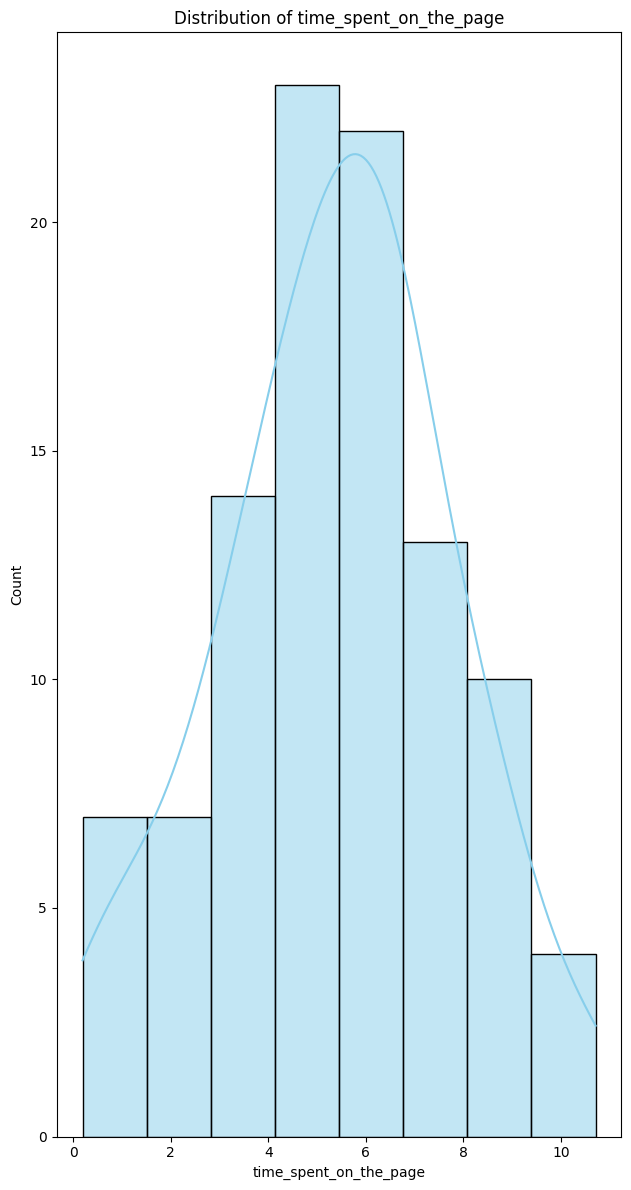

In [ ]:
# Draw all the histogram of numerical columns
# Select only numerical columns
numeric_cols = E_news_Express.select_dtypes(include=['number']).columns

# Define the grid size
n_cols = 3
n_rows = (len(numeric_cols) // n_cols) + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(E_news_Express[col], ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

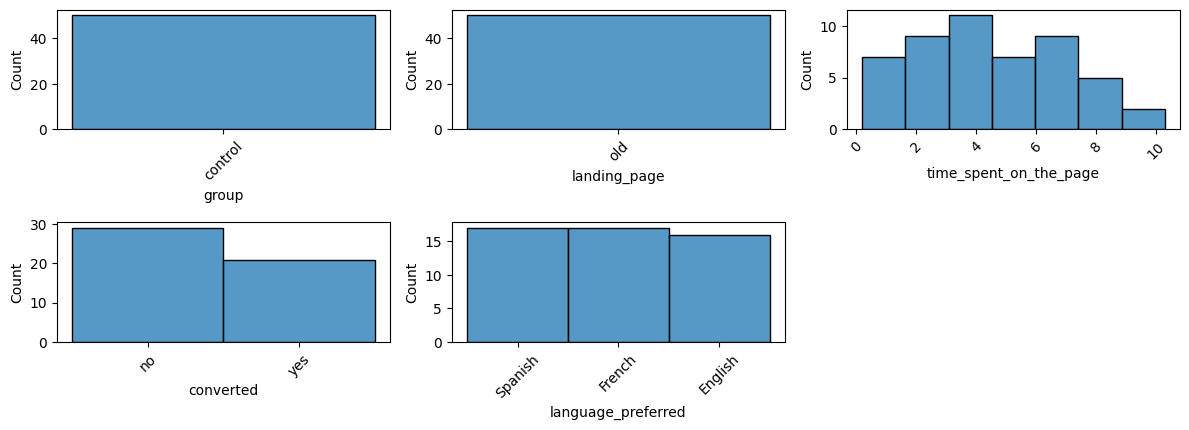

In [ ]:
# Iterate over each numerical features
plt.figure(figsize=(12,10))
for i,feature in enumerate(control_group.columns):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.histplot(control_group,x=feature)

plt.tight_layout()

* There are 50 users in control group
* The time_spent_on_the_page shows slightly right skewed distribution
* The most of the users spent 4 minutes. In control group the users spent 2 to 6 minutes mostly
* In control group, converted users are less compared to non converted users.

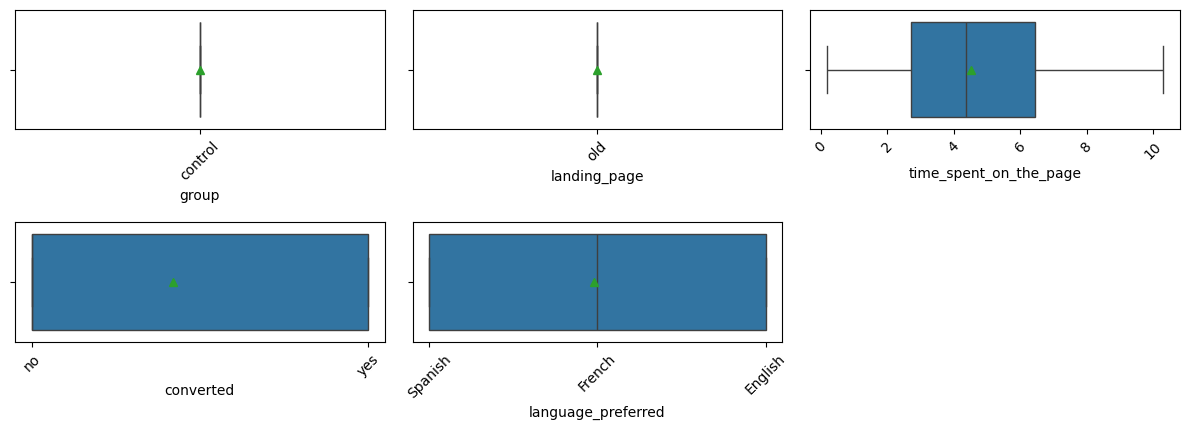

In [ ]:
# draw the boxplot of each columns of control group
plt.figure(figsize=(12,10))
for i,feature in enumerate(control_group.columns):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.boxplot(control_group,x=feature,showmeans=True)

plt.tight_layout()

* There are no outliers present

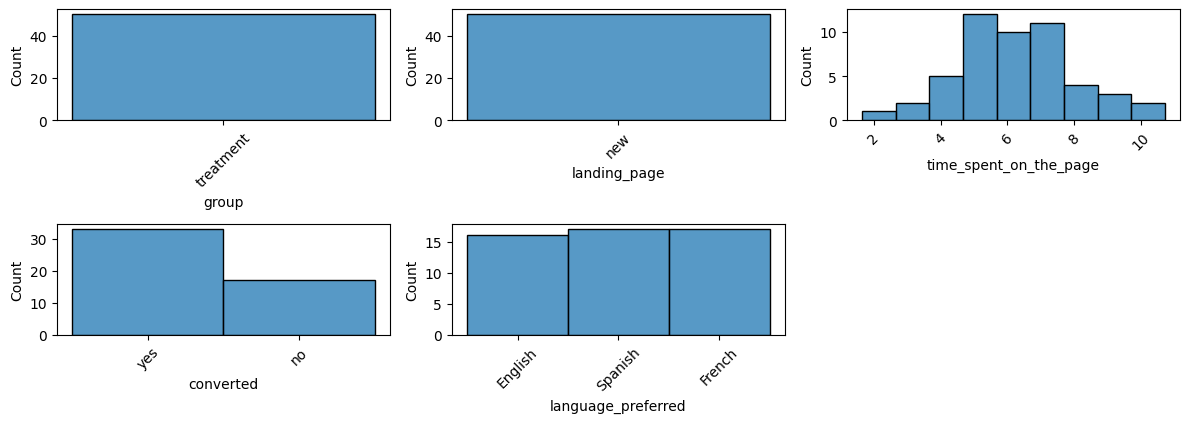

In [ ]:
# draw the histogram of each columns of control group
plt.figure(figsize=(12,10))
for i,feature in enumerate(treatment_group.columns):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.histplot(treatment_group,x=feature)

plt.tight_layout()

* There are 50 users in treatment group
* The time_spent_on_the_page shows normal with slightly right skewed distribution
* The most of the users spent 5 minutes. In treatment group the users spent 2 to 6 minutes mostly
* In treatment group, converted users are more compared to non converted users.

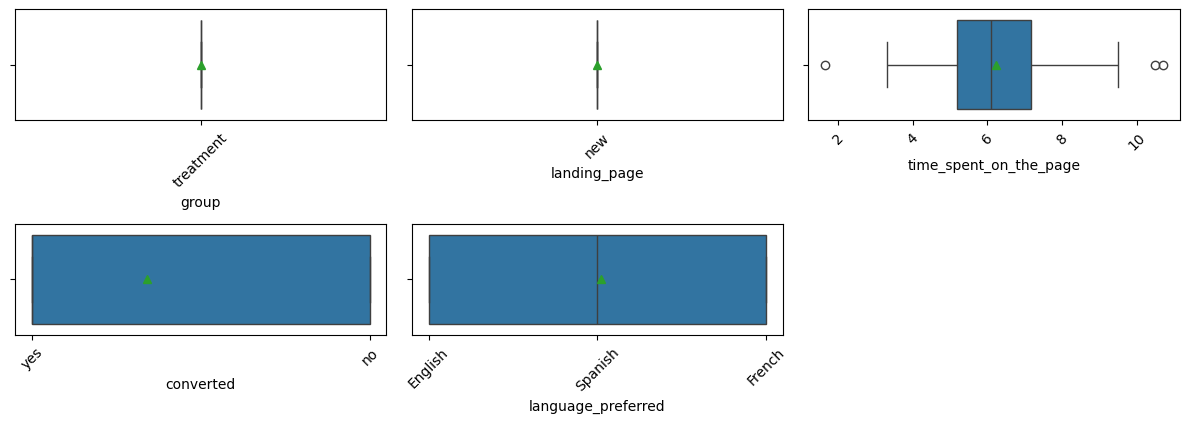

In [ ]:
# draw the boxplot of each columns of control group
plt.figure(figsize=(12,10))
for i,feature in enumerate(treatment_group.columns):
  plt.subplot(5,3,i+1)
  plt.xticks(rotation=45)
  sns.boxplot(treatment_group,x=feature,showmeans=True)

plt.tight_layout()

* The time_spent_on_the_page shows outliers in treatment_group

### Bivariate

### Control group
* Time spent on the page Vs Converted in control group

<Figure size 1000x600 with 0 Axes>

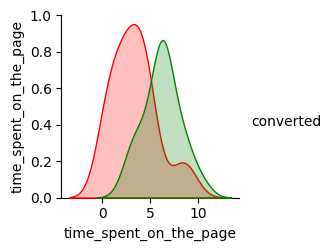

In [ ]:
# Draw a pairplot of time_spent_on_page and converted in control_group
plt.figure(figsize=(10, 6))
sns.pairplot(control_group,
             vars=['time_spent_on_the_page'],
             hue='converted',
             hue_order=['yes', 'no'],
             palette={'yes': 'green', 'no': 'red'})
plt.show()

* Users who converted (green) typically spent more time on the page, around 6 to 7 minutes.

* Users who did not convert (red) tended to leave much sooner, they spend  approximately 3 to 4 minutes.

### Treatment group
 * Time spent on the page Vs Converted in treatment group

<Figure size 1000x600 with 0 Axes>

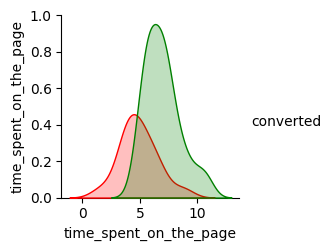

In [ ]:
# Draw a pairplot of time_spent_on_page and converted in treatment_group
plt.figure(figsize=(10, 6))
sns.pairplot(treatment_group,
             vars=['time_spent_on_the_page'],
             hue='converted',
             hue_order=['yes', 'no'],
             palette={'yes': 'green', 'no': 'red'})
plt.show()

* Users who converted (green) spent significantly more time on the page on average than those who did not, with their peak density centered around 6 to 7 units of time.
* The non-converted group (red) shows very less time they spent on page

In [ ]:
# Average time spent by each group in converted
average_time_spent=E_news_Express.groupby(['group', 'converted'])['time_spent_on_the_page'].mean()
display(average_time_spent)

group      converted
control    no           3.349310
           yes          6.166190
treatment  no           4.882353
           yes          6.913939
Name: time_spent_on_the_page, dtype: float64

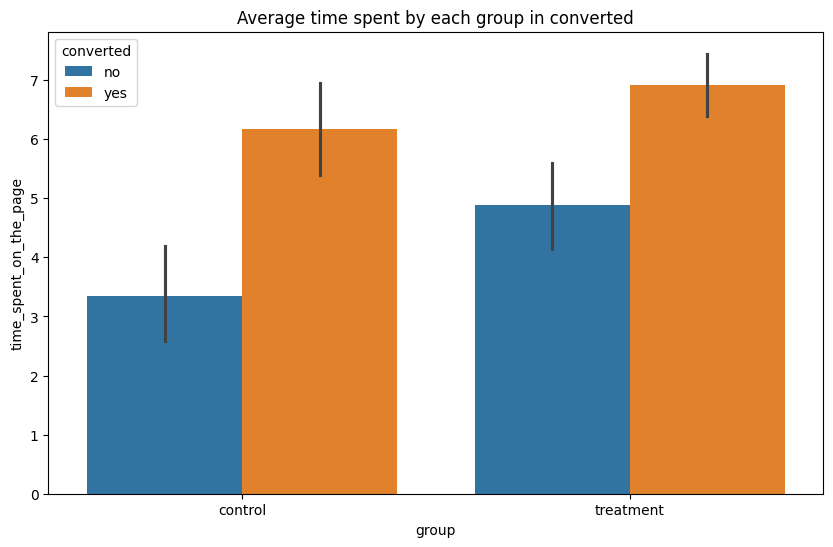

In [ ]:
#visualise average time spent by each group in converted
plt.figure(figsize=(10, 6))
sns.barplot(data=E_news_Express,x='group',y='time_spent_on_the_page',hue='converted')
plt.title('Average time spent by each group in converted')

plt.show()

* The bar chart shows that, in both the control and treatment groups, those who converted ("yes") spent noticeably longer average time on the page than those who did not.
* Regardless of their conversion status, participants in the treatment group often showed longer engagement periods than those in the control group.


### Average time spent by language speakers in each group

In [ ]:
average_time_spent = E_news_Express.groupby(['group', 'language_preferred'])['time_spent_on_the_page'].mean()
display(average_time_spent)

group      language_preferred
control    English               4.454375
           French                4.310000
           Spanish               4.828235
treatment  English               6.663750
           French                6.196471
           Spanish               5.835294
Name: time_spent_on_the_page, dtype: float64

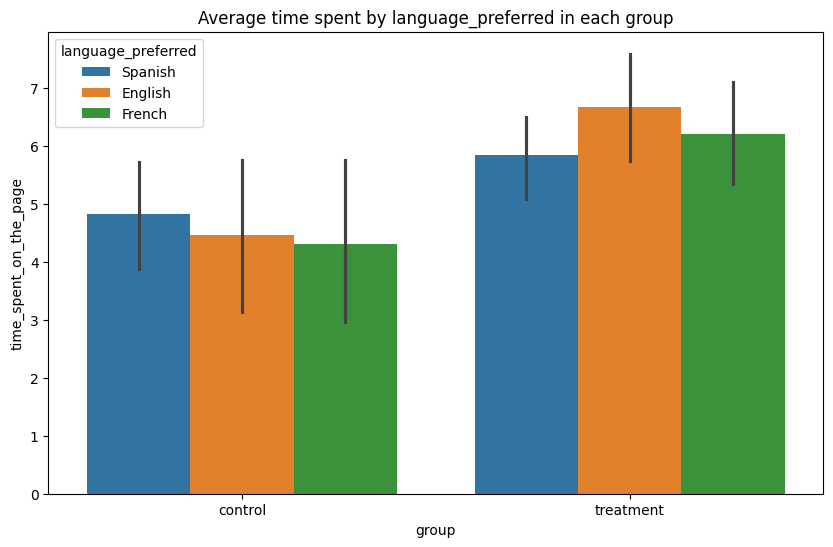

In [ ]:
##visualise average time spent by language speakers in each group
plt.figure(figsize=(10, 6))
sns.barplot(data=E_news_Express,x='group',y='time_spent_on_the_page',hue='language_preferred')
plt.title('Average time spent by language_preferred in each group')

plt.show()

* The bar chart indicates that, on average, the treatment group spent more time on the page than the control group in all three of their languages—Spanish, English, and French.

* Users who chose English spent the most time on average (almost 7 minutes) in the treatment group, while those who preferred Spanish had the highest average in the control group (nearly 5 minutes).

### Average time spent by language speakers in each group by considering conversion

In [ ]:
average_time_spent = E_news_Express.groupby(['group', 'language_preferred','converted'])['time_spent_on_the_page'].mean()
display(average_time_spent)

group      language_preferred  converted
control    English             no           1.776000
                               yes          5.671818
           French              no           3.669286
                               yes          7.300000
           Spanish             no           3.688000
                               yes          6.457143
treatment  English             no           5.506667
                               yes          7.358000
           French              no           4.400000
                               yes          6.945000
           Spanish             no           4.660000
                               yes          6.476364
Name: time_spent_on_the_page, dtype: float64

<Figure size 1000x600 with 0 Axes>

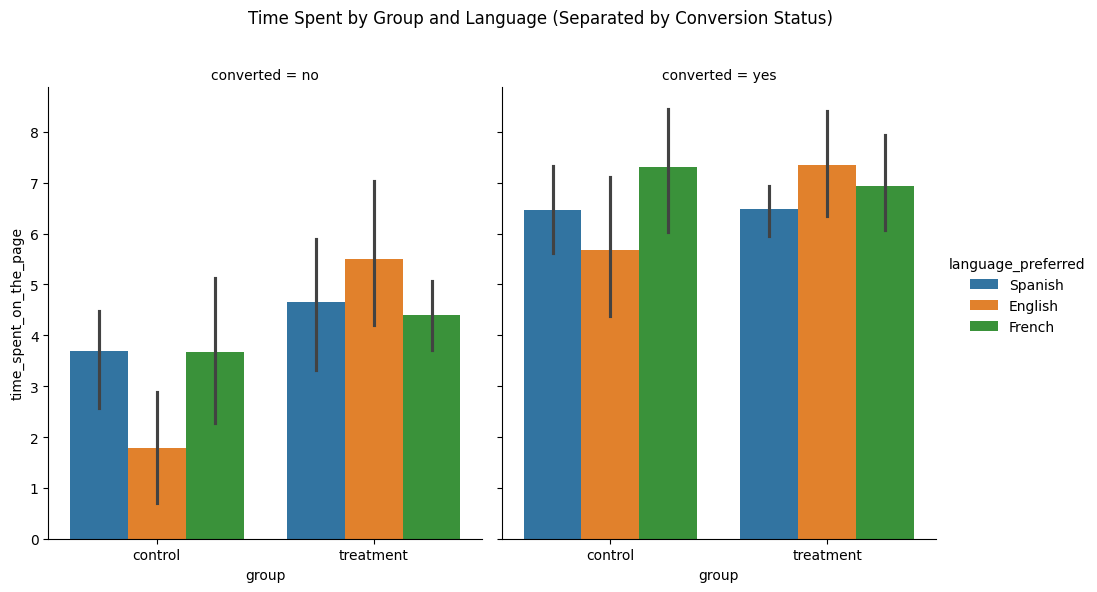

In [ ]:
# visualise the average time spent by language speakers in each group by considering conversion
plt.figure(figsize=(10, 6))
sns.catplot(
    data=E_news_Express,
    x='group',
    y='time_spent_on_the_page',
    hue='language_preferred',
    col='converted', # This creates the side-by-side columns
    kind='bar',
    height=6,
    aspect=0.8
)

plt.subplots_adjust(top=0.85)
plt.suptitle('Time Spent by Group and Language (Separated by Conversion Status)')
plt.show()

* Users who converted spent an average of 6–7.5 minutes more on the page than those who did not, regardless of language preferences and demographics.

* For non-converters, the treatment group typically exhibits greater engagement than the control group, but for those who converted, the amount of time spent is consistently high regardless of the group or language.

Text(0, 0.5, 'Frequency')

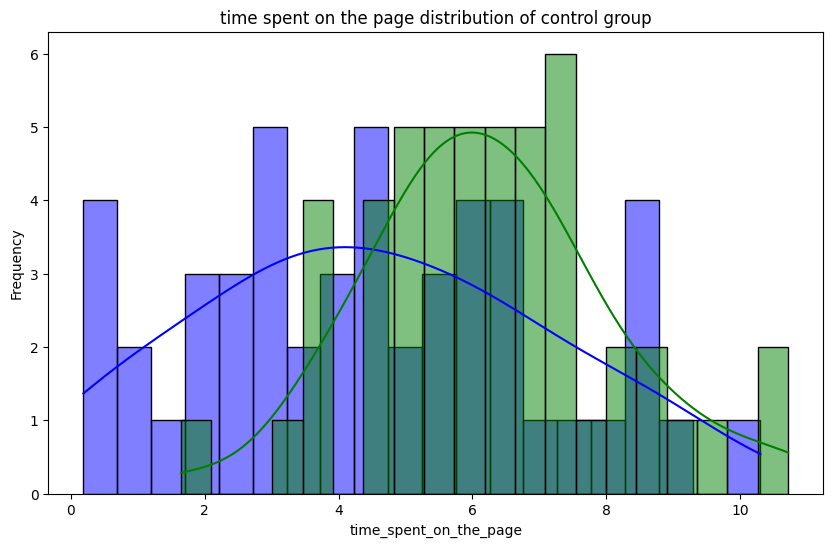

In [ ]:
#plot the histogram distribution of each group spending time
plt.figure(figsize=(10, 6))
sns.histplot(control_group['time_spent_on_the_page'], bins=20, kde=True, color='blue', label='control')
sns.histplot(treatment_group['time_spent_on_the_page'], bins=20, kde=True, color='green', label='Treatment')
plt.title('time spent on the page distribution of each group')
plt.xlabel('time_spent_on_the_page')
plt.ylabel('Frequency')

* In comparison to the blue distribution (control group), the green distribution (treatment group) exhibits a smaller variance and a greater mean engagement, indicating that the modifications were successful in extending the amount of time spent on the page.

* The treatment group is more closely grouped around a higher peak of roughly 6 to 7 minutes, whereas the control group has a wider, more scattered range of user behavior.

### Hypothesis tesing
### 1. Do the users spend more time on the new landing page than the old landing page?

### Step 1: Define null and alternative hypotheses

Do the users spend more time on the new landing page than the old landing page?<br>
The null and alternative hypotheses can be formulated as:

> $H_0:$ The mean usage time on the new landing page is less than or equal to the  mean usage time on the old landing page <br>
> $H_a:$ The mean usage time on the new landing page is greater than or equal to the  mean usage time on the old landing page

Let $\mu$ be the mean usage time on the landing page by the users <br>
$\mu_{new}$ : mean usage time on the new landing page <br>
$\mu_{old}$ : mean usage time on the old landing page

Mathematically, the above formulated hypotheses can be written as:

>$H_0: \mu_{new} <= \mu_{old} $ <br>
$H_a: \mu_{new} >\mu_{old} $


### Step 2: Select Appropriate test

* This is a case of a one-tailed (right-tailed) test for a single mean's significance. The two-sample t-test is the proper statistical test to compare the mean usage duration between two independent groups (new landing page vs. old landing page), as the population standard deviation is unknown.

### Two sample t test
* Comparing two independent groups' means
Time spent is a continuous outcome variable.
* One-tailed hypothesis (determining whether new is greater than old)
Sample sizes (n = 50 per category) seem sufficient.Given that the sample was chosen at random, we assume that it originates from a population that is regularly distributed.

### Step 3: Decide the significance level

* As given in the problem statement, we select $\alpha = 0.05$.

### Step 4: Find Mean and Std of each group

In [ ]:
# calculate the mean and standard deviation of two samples
mean_new = treatment_group['time_spent_on_the_page'].mean()
mean_old = control_group['time_spent_on_the_page'].mean()
print("The mean usage time of control group is",mean_old)
print("The mean usage time of treatment group is",mean_new)
std_new = round(treatment_group['time_spent_on_the_page'].std(),2)
std_old = round(control_group['time_spent_on_the_page'].std(),2)
print("The standard deviation usage time of control group is",std_old)
print("The standard deviation usage time of treatment group is",std_new)

The mean usage time of control group is 4.532400000000001
The mean usage time of treatment group is 6.2232
The standard deviation usage time of control group is 2.58
The standard deviation usage time of treatment group is 1.82


### Step 5: Calculate the p-value

- We will use the `ttest_ind()` function from the `scipy.stats` library to perform a two-sample t-test.
- The `ttest_ind()` function takes the sample observations, hypothesized population mean and the direction of the alternative hypothesis as input and returns the test statistic and the p-value for the test.
    - The sample observations are the values of usage time on the landing page in the dataset.
    - The sample variances of old and new landing apges are not equal
    - As it is a one-tailed test, we will set the argument `alternative = 'one-sided'`

In [ ]:

# Extract the time spent data for both groups
treatment_time = treatment_group['time_spent_on_the_page']
control_time = control_group['time_spent_on_the_page']

# Does NOT assume equal variances
t_stat, p_value_right_tailed = stats.ttest_ind(
    treatment_time,
    control_time,
    equal_var=False,
    alternative='greater'
)
# Check direction of t-statistic for right-tailed test
if t_stat > 0:
    print("T-statistic is positive (treatment mean > control mean)")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value (right-tailed): {p_value_right_tailed:.4f}")
else:
    print("T-statistic is negative (treatment mean < control mean)")
    print("Cannot reject null hypothesis for right-tailed test")




T-statistic is positive (treatment mean > control mean)
T-statistic: 3.7868
P-value (right-tailed): 0.0001


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# print the conclusion based on p-value
# Decision at α = 0.05
alpha = 0.05

print("Hypothesis Test Results")
print(f"Significance Level (α): {alpha}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value (right-tailed): {p_value_right_tailed:.4f}")

if p_value_right_tailed < alpha:
    print(f"\nREJECT H₀ (p-value {p_value_right_tailed:.4f} < {alpha})")
    print("Conclusion: Users spend SIGNIFICANTLY MORE time on the new landing page")
else:
    print(f"\nFAIL TO REJECT H₀ (p-value {p_value_right_tailed:.4f} ≥ {alpha})")
    print("Conclusion: No significant evidence that new page increases time spent")



Hypothesis Test Results
Significance Level (α): 0.05
T-statistic: 3.7868
P-value (right-tailed): 0.0001

REJECT H₀ (p-value 0.0001 < 0.05)
Conclusion: Users spend SIGNIFICANTLY MORE time on the new landing page


### Step 7: Draw Inference

* Reject the null hypothesis at a significance level of 5%. Therefore, we have sufficient statistical data to conclude that user spend a higher average amount of time on the new landing page than on the old one.

## Hypothesis Testing

### 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

### Step 1: Define null and alternative hypotheses

<br>
The null and alternative hypotheses can be formulated as:<br>

> $H_0:$ The conversion rate for the new page is less than or equal to the conversion rate for the old page <br>
> $H_a:$ The conversion rate for the new page is greater than the conversion rate for the old page
<br>
$P_{new}$ : proportion of conversions on new landing page<br>
$P_{old}$ : proportion of conversions on old landing page <br><br>
Mathematically, the above formulated hypotheses can be written as:

>$H_0: P_{new} <= P_{old} $ <br>
$H_a: P_{new} >P_{old} $

### Step 2: Select Appropriate test

For comparing conversion rates (proportions) between two groups, the appropriate statistical test is: Two-Proportion Z-Test. <br>
- Comparing proportions (conversion rates) between two independent groups
- Binary outcome (converted: yes/no)
- Large sample sizes (n ≥ 30 per group)
- Independent samples

### Step 3: Decide the significance level

As given in the problem statement, we select $\alpha = 0.05$.

### Step 5 : Calculate the Proportions

In [ ]:
# Calculate conversion counts
# Count conversions (yes) in each group
treatment_conversions = treatment_group[treatment_group['converted'] == 'yes'].shape[0]
control_conversions = control_group[control_group['converted'] == 'yes'].shape[0]

# Total sample sizes
treatment_count = len(treatment_group)
control_count = len(control_group)

# Calculate conversion rates
treatment_rate = treatment_conversions / treatment_count
control_rate = control_conversions / control_count


print("Conversion rate summary")
print(f"Treatment Group (New Page):")
print(f"  Conversions: {treatment_conversions} / {treatment_count}")
print(f"  Conversion Rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)")
print(f"\nControl Group (Old Page):")
print(f"  Conversions: {control_conversions} / {control_count}")
print(f"  Conversion Rate: {control_rate:.4f} ({control_rate*100:.2f}%)")
print(f"\nDifference: {treatment_rate - control_rate:.4f} ({(treatment_rate - control_rate)*100:.2f}%)")


Conversion rate summary
Treatment Group (New Page):
  Conversions: 33 / 50
  Conversion Rate: 0.6600 (66.00%)

Control Group (Old Page):
  Conversions: 21 / 50
  Conversion Rate: 0.4200 (42.00%)

Difference: 0.2400 (24.00%)


### Step 6: Calculate the p-value

- We will use the `proportions_ztest()` function from the `scipy.stats` library to perform a two-sample t-test.
- The `proportions_ztest()` function takes the sample observations, hypothesized population mean and the direction of the alternative hypothesis as input and returns the test statistic and the p-value for the test.
    - The sample observations are the values of usage time on the landing page in the dataset.
    - As it is a one-tailed test, we will set the argument `alternative = 'larger'`

In [ ]:
# Two-Proportion Z-Test
# Combine counts and n for the test
count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_count, control_count])

# Perform Z-test (right-tailed: 'larger')
from statsmodels.stats.proportion import proportions_ztest
z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='larger'
)


print("Two- Proportion Z-test Results")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (right-tailed): {p_value:.6f}")



Two- Proportion Z-test Results
Z-statistic: 2.4077
P-value (right-tailed): 0.008026


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# Hypothesis Test Decision
alpha = 0.05

print(f"\nSignificance Level (α): {alpha}")
print("\nH₀: p_new ≤ p_old")
print("Hₐ: p_new > p_old")

if p_value < alpha:
    print("Reject the null hypothesis")
    print(f"  P-value ({p_value:.6f}) < α ({alpha})")
    print("\nCONCLUSION: The new landing page has a SIGNIFICANTLY HIGHER conversion rate than the old landing page")
else:
    print(f"\n Fail to reject the null hypothesis")
    print(f"  P-value ({p_value:.6f}) ≥ α ({alpha})")
    print("\nCONCLUSION: No significant evidence that the new landing page has a higher conversion rate")



Significance Level (α): 0.05

H₀: p_new ≤ p_old
Hₐ: p_new > p_old
Reject the null hypothesis
  P-value (0.008026) < α (0.05)

CONCLUSION: The new landing page has a SIGNIFICANTLY HIGHER conversion rate than the old landing page


### Step 7: Draw Inference

* At a significance level of 5%,We reject the null hypothesis  Therefore, we have not sufficient statistical data to conclude that the new landing page has a higher conversion rate than the previous one.

## Hypothesis Testing

### 3. Does the converted status depend on the preferred language?

### Step 1: Define null and alternative hypotheses

<br>
The null and alternative hypotheses can be formulated as:<br>

> $H_0:$  Conversion status and preferred language are independent (no association) <br>
> $H_a:$ Conversion status and preferred language are dependent (associated)
<br>
Mathematically, the above formulated hypotheses can be written as:

>$H_0:P(converted∣language)=P(converted)∀ $ languages <br>
$H_a: P(converted∣language)=P(converted)$for at least one language


### Step 2: Select Appropriate test

* To test whether conversion status (binary: yes/no) depends on preferred language (categorical: Spanish/French/English), we will use test for independence between two categorical variables, the Chi-Square Test of Independence
- Both variables are categorical (converted: yes/no; language: Spanish/French/English)
- Testing for association/dependence between variables
- Sample size is adequate (expected cell counts ≥ 5)

### Step 3: Decide the significance level

* As given in the problem statement, we select $\alpha = 0.05$.

### Step 4: Prepare Data for Test

In [ ]:
# Create Contingency Table

contingency_table = pd.crosstab(
    E_news_Express['language_preferred'],  # Rows
    E_news_Express['converted'],           # Columns
    margins=True               # Add totals
)

print("="*60)
print("CONTINGENCY TABLE: Language vs Conversion")
print("="*60)
print(contingency_table)
print("="*60)

CONTINGENCY TABLE: Language vs Conversion
converted           no  yes  All
language_preferred              
English             11   21   32
French              19   15   34
Spanish             16   18   34
All                 46   54  100


### Step 5 : Calculate the Proportions

In [ ]:
# Calculate conversion counts
# Count conversions (yes) in each group
treatment_conversions = treatment_group[treatment_group['converted'] == 'yes'].shape[0]
control_conversions = control_group[control_group['converted'] == 'yes'].shape[0]

# Total sample sizes
treatment_count= len(treatment_group)
control_count = len(control_group)

# Calculate conversion rates
treatment_rate = treatment_conversions / treatment_count
control_rate = control_conversions / control_count


print("Conversion rate summary")
print(f"Treatment Group (New Page):")
print(f"  Conversions: {treatment_conversions} / {treatment_count}")
print(f"  Conversion Rate: {treatment_rate:.4f} ({treatment_rate*100:.2f}%)")
print(f"\nControl Group (Old Page):")
print(f"  Conversions: {control_conversions} / {control_count}")
print(f"  Conversion Rate: {control_rate:.4f} ({control_rate*100:.2f}%)")
print(f"\nDifference: {treatment_rate - control_rate:.4f} ({(treatment_rate - control_rate)*100:.2f}%)")


Conversion rate summary
Treatment Group (New Page):
  Conversions: 33 / 50
  Conversion Rate: 0.6600 (66.00%)

Control Group (Old Page):
  Conversions: 21 / 50
  Conversion Rate: 0.4200 (42.00%)

Difference: 0.2400 (24.00%)


### Step 6: Calculate the p-value

- We will use the `proportions_ztest()` function from the `scipy.stats` library to perform a two-sample t-test.
- The `proportions_ztest()` function takes the sample observations, hypothesized population mean and the direction of the alternative hypothesis as input and returns the test statistic and the p-value for the test.
    - The sample observations are the values of usage time on the landing page in the dataset.
    - As it is a one-tailed test, we will set the argument `alternative = 'larger'`

In [ ]:
# Two-Proportion Z-Test
# Combine counts and n for the test
count = np.array([treatment_conversions, control_conversions])
nobs = np.array([treatment_count, control_count])

# Perform Z-test (right-tailed: 'larger')
z_stat, p_value = proportions_ztest(
    count,
    nobs,
    alternative='larger'
)


print("Two- Proportion Z-test Results")

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (right-tailed): {p_value:.6f}")



Two- Proportion Z-test Results
Z-statistic: 2.4077
P-value (right-tailed): 0.008026


### Step 6: Compare the p-value with $\alpha$

In [ ]:
# Hypothesis Test Decision
alpha = 0.05

print(f"\nSignificance Level (α): {alpha}")
print("\nH₀: p_new ≤ p_old")
print("Hₐ: p_new > p_old")

if p_value < alpha:
    print("Reject the null hypothesis")
    print(f"  P-value ({p_value:.6f}) < α ({alpha})")
    print("\nCONCLUSION: The new landing page has a SIGNIFICANTLY HIGHER conversion rate than the old landing page")
else:
    print(f"\n Fail to reject the null hypothesis")
    print(f"  P-value ({p_value:.6f}) ≥ α ({alpha})")
    print("\nCONCLUSION: No significant evidence that the new landing page has a higher conversion rate")


Significance Level (α): 0.05

H₀: p_new ≤ p_old
Hₐ: p_new > p_old
Reject the null hypothesis
  P-value (0.008026) < α (0.05)

CONCLUSION: The new landing page has a SIGNIFICANTLY HIGHER conversion rate than the old landing page


### Step 7: Draw Inference

At a 5% significance level, we reject the null hypothesis. Hence, we have enough statistical evidence to say that the new landing page has higher conversion rate than the old landing page.

### Hypothesis Testing
### 4. Is the time spent on the new page the same for the different language users?


 ### Step1:Define null and alternative hypothesis

The null and alternative hypotheses can be formulated as:

> **$H_0$:** The mean time spent on the new page is equal across all language user groups.  
> **$H_a$:** At least one language group has a different mean time spent on the new page.

Mathematically, the above formulated hypotheses can be written as:

> $H_0: \mu_{\text{English}} = \mu_{\text{Spanish}} = \mu_{\text{French}}$  
> $H_a: \text{At least one } \mu_i \text{ is different}$


### Step 2: Select Appropriate Test




Three or more different user language-based categories—English, Spanish, and French groups—are included.This is a problem, concerning three population means. Instead of using a Z-test, a sample-based statistical test is required when the population standard deviation is unknown. One-way ANOVA is an appropriate test here provided normality and equality of variance assumptions are verified.

**One-way ANOVA test**

In a one-way ANOVA test, we compare the means from several populations to test if there is any significance difference between them. The results from an ANOVA test are most reliable when the assumptions of normality and equality of variances are satisfied.

* For testing of normality, Shapiro-Wilk’s test is applied to the response variable.

* For equality of variance, Levene test is applied to the response variable.

In [ ]:
# 🔑 CRITICAL: Filter for NEW page only
New_E_news_Express = E_news_Express[E_news_Express['landing_page'] == 'new'].copy()

print("Dataset filtered for NEW landing page:")
print(New_E_news_Express[['time_spent_on_the_page', 'language_preferred']])
print(f"\nSample sizes per language: {New_E_news_Express['language_preferred'].value_counts().to_dict()}")

Dataset filtered for NEW landing page:
    time_spent_on_the_page language_preferred
1                     7.13            English
2                     4.40            Spanish
4                     4.75            Spanish
6                     5.25             French
8                    10.71             French
12                    5.86            Spanish
13                    6.03             French
15                    6.27            Spanish
16                    8.73            English
22                    3.65            English
23                    7.02            English
24                    6.18            Spanish
25                    4.39            English
26                    9.49            English
28                    7.81             French
30                    5.41            English
38                    1.65            Spanish
42                    7.16            Spanish
43                    7.16            English
44                    3.91            Eng

**Shapiro-Wilk’s test**

We will test the null hypothesis

>$H_0:$ The time spent on new page follow a normal distribution

against the alternative hypothesis

>$H_a:$ The time spent on new page do not not follow a normal distribution

In [ ]:
# Assumption 1: Normality
# Use the shapiro function for the scipy.stats library for this test

# find the p-value
w, p_value = stats.shapiro(New_E_news_Express['time_spent_on_the_page'])
print('The p-value is', p_value)

The p-value is 0.8040040364746845


Since p-value of the test is very large than the 5% significance level, we fail to reject the null hypothesis that the response follows the normal distribution.

**Levene’s test**

We will test the null hypothesis

>$H_0$: All the population variances are equal

against the alternative hypothesis

>$H_a$: At least one variance is different from the rest

In [ ]:
#Assumption 2: Homogeneity of Variance
# use levene function from scipy.stats library for this test

# find the p-value
statistic, p_value = stats.levene(New_E_news_Express[New_E_news_Express['language_preferred']=='Spanish']['time_spent_on_the_page'],
                            New_E_news_Express[New_E_news_Express['language_preferred']=='French']['time_spent_on_the_page'],
                            New_E_news_Express[New_E_news_Express['language_preferred']=='English']['time_spent_on_the_page'])
print('The p-value is', p_value)

The p-value is 0.46711357711340173


Since the p-value is large than the 5% significance level, we fail to reject the null hypothesis of homogeneity of variances.

### Step 3: Decide the significance level

* As given in the problem statement, we select $\alpha = 0.05$.

### **Step 4: Collect and prepare data**

In [ ]:
# create separate variables to store the time spent on new page with respect to the three languages
Time_spent_on_new_page_Spanish= New_E_news_Express[New_E_news_Express['language_preferred']=='Spanish']['time_spent_on_the_page']
Time_spent_on_new_page_French = New_E_news_Express[New_E_news_Express['language_preferred']=='French']['time_spent_on_the_page']
Time_spent_on_new_page_English = New_E_news_Express[New_E_news_Express['language_preferred']=='English']['time_spent_on_the_page']

### Step 5: Calculate P value

- We will use the `f_oneway()` function from the `scipy.stats` library to perform a one-way ANOVA test.
- The `f_oneway()` function takes the sample observations from the different groups and returns the test statistic and the p-value for the test.
    - The sample observations are the values of time spent on new page with respect to the three language prefered.

In [ ]:
# import the required function
from scipy.stats import f_oneway

# find the p-value
test_stat, p_value = f_oneway(Time_spent_on_new_page_Spanish, Time_spent_on_new_page_French, Time_spent_on_new_page_English)
print('The p-value is ', p_value)

The p-value is  0.43204138694325955


### **Step 6: Compare the p-value with $\alpha$**

In [ ]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.43204138694325955 is greater than the level of significance, we fail to reject the null hypothesis.


### **Step 7:  Draw inference**

We fail to reject the null hypothesis since the ANOVA p-value of 0.432, which is more than the significance level of α = 0.05, shows that there is no statistically significant difference in the mean amount of time spent on the new page among the English, Spanish, and French language groups.

### Conclusions

* The statistical rejection of the null hypothesis for time spent indicates that the new landing page is significantly more engaging than the old version

* Analysis confirms that the conversion rate for the treatment group is significantly higher than the control group.

* The new design has successfully solved the primary business objective: gathering new subscribers.

* The analysis confirms that the conversion rate for the new page is statistically greater than that of the old page.

* Analysis suggests that the actual "Converted" status depends on the preferred language.

* Messaging may need slight cultural/translation tuning.

* The ANOVA results (p-value = 0.432) show that the time spent on the new page is consistent across English, Spanish, and French speakers

* The new landing page performs consistently regardless of whether the user prefers English, Spanish, or French.

* It indicates that do not require immediate language-specific structural adjustments to maintain engagement.

